# Analisis Data Eksploratif Spotify App

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import re

# Konfigurasi tampilan
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

available_styles = matplotlib.style.available
if 'seaborn-v0_8' in available_styles:
    plt.style.use('seaborn-v0_8')
elif 'seaborn' in available_styles:
    plt.style.use('seaborn')
else:
    plt.style.use('ggplot')

pd.set_option('display.max_colwidth', 200)
print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## Load Dataset

In [30]:
# Load dataset ulasan Spotify
df_spotify = pd.read_csv('../out/rawdata_spotify_id.csv', low_memory=False)
df_spotify.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,95fe611e-c2b2-435c-bba2-bd589c7d8cc6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,terima kasih Spotify sudah menyediakan lagu_lagu untuk kami,5,0,NaN,2026-04-07 13:41:34,NaN,NaN,NaN
1,2c563637-cfe6-4dcc-9b2e-1e1ab3f3883a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,👍🏼👍🏼👍🏼,5,0,9.1.32.2083,2026-04-07 13:33:14,NaN,NaN,9.1.32.2083
2,a5b1eaad-3605-4c20-b55a-1cb6bebeb857,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,sebenarnya ini tuh udah bagus banget apknya cuman tiap dengerin musik suka tiba-tiba iklan🥰.. dan itu nyebelin dan risih bgt buat gw😭🤗maaf ya devnyaa😇..,4,0,NaN,2026-04-07 13:31:21,NaN,NaN,NaN
3,05c4415f-1a32-4b31-9f75-1c8b725f3e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,bagus banget,5,0,NaN,2026-04-07 13:08:57,NaN,NaN,NaN
4,d5236114-519c-4502-a94f-571f5d25a9eb,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Bagus sekali,5,0,9.1.34.2060,2026-04-07 13:00:41,NaN,NaN,9.1.34.2060


In [31]:
# Ringkasan informasi dataset
df_spotify.info()

<class 'pandas.DataFrame'>
RangeIndex: 482756 entries, 0 to 482755
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              482756 non-null  str  
 1   userName              482756 non-null  str  
 2   userImage             482756 non-null  str  
 3   content               482741 non-null  str  
 4   score                 482756 non-null  int64
 5   thumbsUpCount         482756 non-null  int64
 6   reviewCreatedVersion  326735 non-null  str  
 7   at                    482756 non-null  str  
 8   replyContent          4903 non-null    str  
 9   repliedAt             4903 non-null    str  
 10  appVersion            326735 non-null  str  
dtypes: int64(2), str(9)
memory usage: 40.5 MB


## Transformasi Format Data Waktu

Kolom `at` yang semula bertipe string dikonversi ke format `datetime` agar analisis berbasis waktu dapat dilakukan secara kronologis. Validasi tipe data dilakukan setelah proses konversi untuk memastikan struktur kolom telah sesuai.

In [32]:
df_spotify['at'] = pd.to_datetime(df_spotify['at'])
df_spotify.info()

<class 'pandas.DataFrame'>
RangeIndex: 482756 entries, 0 to 482755
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              482756 non-null  str           
 1   userName              482756 non-null  str           
 2   userImage             482756 non-null  str           
 3   content               482741 non-null  str           
 4   score                 482756 non-null  int64         
 5   thumbsUpCount         482756 non-null  int64         
 6   reviewCreatedVersion  326735 non-null  str           
 7   at                    482756 non-null  datetime64[us]
 8   replyContent          4903 non-null    str           
 9   repliedAt             4903 non-null    str           
 10  appVersion            326735 non-null  str           
dtypes: datetime64[us](1), int64(2), str(8)
memory usage: 40.5 MB


## Distribusi Skor Ulasan

Perhitungan proporsi jumlah ulasan pada setiap tingkatan rating (1–5 bintang) dilakukan untuk mendeteksi potensi ketidakseimbangan data (*data imbalance*) yang dapat memengaruhi hasil pemodelan sentimen.

In [33]:
df_spotify['score'].value_counts()

score
5    319518
1     64388
4     51152
3     30075
2     17623
Name: count, dtype: int64

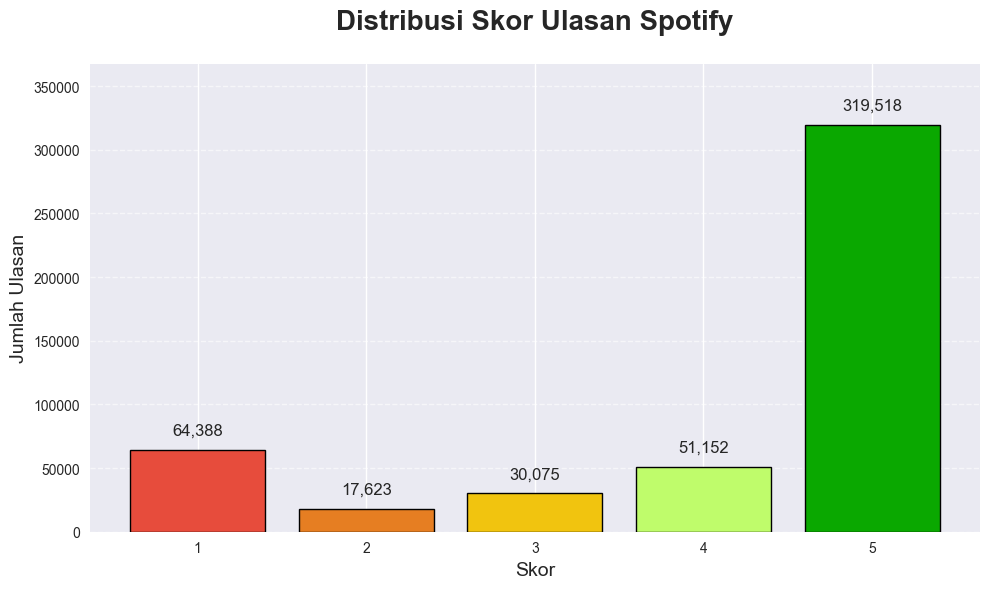

In [34]:
df_count = df_spotify['score'].value_counts().sort_index()

score_colors = {
    1: '#e74c3c',
    2: '#e67e22',
    3: '#f1c40f',
    4: '#bffc6b',
    5: '#0aa800',
}
colors = [score_colors[s] for s in df_count.index]

plt.figure(figsize=(10, 6))
bars = plt.bar(df_count.index, df_count.values, color=colors, edgecolor='black', linewidth=1)

plt.title('Distribusi Skor Ulasan Spotify', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Skor', fontsize=14)
plt.ylabel('Jumlah Ulasan', fontsize=14)

max_val = max(df_count.values)
plt.ylim(top=max_val * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max_val * 0.03,
        f"{height:,}",
        ha='center', va='bottom', fontsize=12
    )

plt.tight_layout()
plt.show()

## Distribusi

/tmp/ipykernel_161810/2544120093.py:37: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/home/ergia/Documents/codes/pba-individu/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


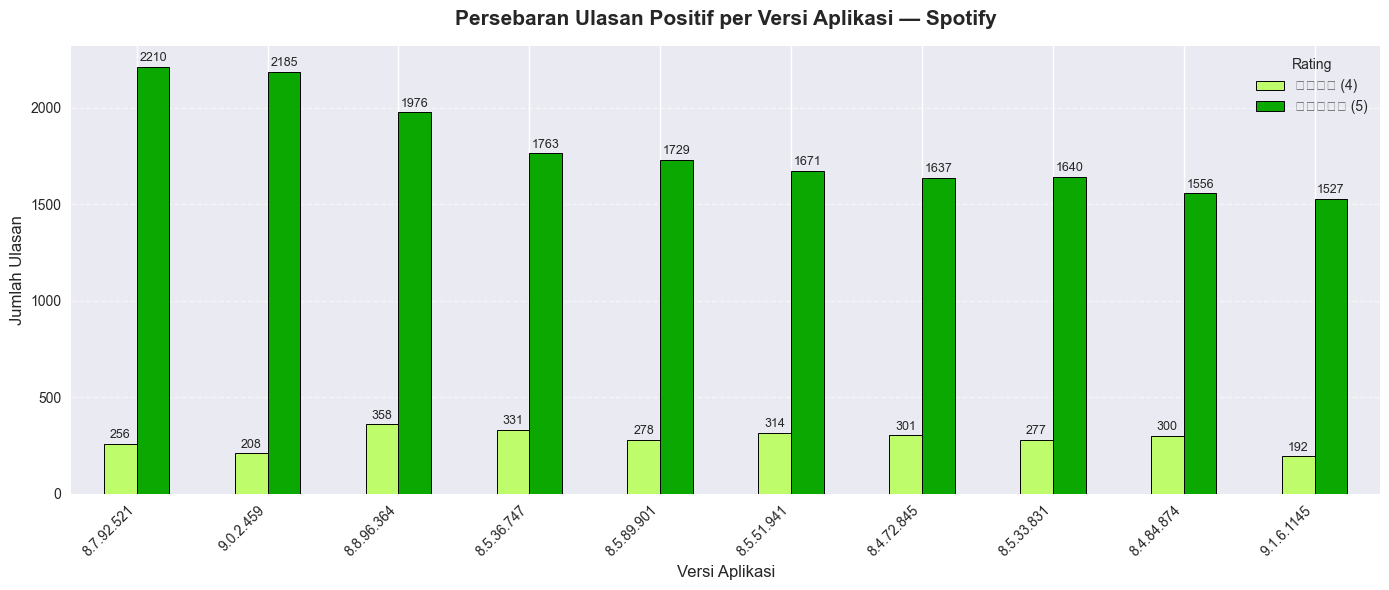

=== RINGKASAN ULASAN POSITIF PER VERSI (TOP 10) ===


,Rating 4,Rating 5,Total Positif
reviewCreatedVersion,,,
8.7.92.521,256,2210,2466
9.0.2.459,208,2185,2393
8.8.96.364,358,1976,2334
8.5.36.747,331,1763,2094
8.5.89.901,278,1729,2007
8.5.51.941,314,1671,1985
8.4.72.845,301,1637,1938
8.5.33.831,277,1640,1917
8.4.84.874,300,1556,1856


In [35]:
# Persebaran Respon Positif per Versi Aplikasi berdasarkan Rating

# Filter hanya rating positif (score 4 dan 5)
df_positive = df_spotify[df_spotify['score'] >= 4].copy()

# Hapus baris tanpa info versi
df_positive = df_positive[df_positive['reviewCreatedVersion'].notna()]

# Hitung jumlah ulasan positif per versi dan per skor
df_pivot = df_positive.groupby(['reviewCreatedVersion', 'score']).size().unstack(fill_value=0)

# Ambil top 10 versi dengan total ulasan positif terbanyak
df_pivot['total'] = df_pivot.sum(axis=1)
df_pivot = df_pivot.nlargest(10, 'total').drop(columns='total')

# Visualisasi
ax = df_pivot.plot(
    kind='bar',
    figsize=(14, 6),
    color={4: '#bffc6b', 5: '#0aa800'},
    edgecolor='black',
    linewidth=0.7
)

plt.title('Persebaran Ulasan Positif per Versi Aplikasi — Spotify',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Versi Aplikasi', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rating', labels=['⭐⭐⭐⭐ (4)', '⭐⭐⭐⭐⭐ (5)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tambah label nilai di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

# Tampilkan tabel ringkasan
print('=== RINGKASAN ULASAN POSITIF PER VERSI (TOP 10) ===')
df_pivot['Total Positif'] = df_pivot.sum(axis=1)
df_pivot.columns = ['Rating 4', 'Rating 5', 'Total Positif']
display(df_pivot.sort_values('Total Positif', ascending=False))

## Tren Frekuensi Ulasan Tahunan

Analisis volume ulasan yang masuk per tahun dilakukan untuk memetakan dinamika pertumbuhan pengguna aplikasi Spotify dari waktu ke waktu. Observasi ini penting untuk memastikan dataset mencakup rentang waktu yang representatif.

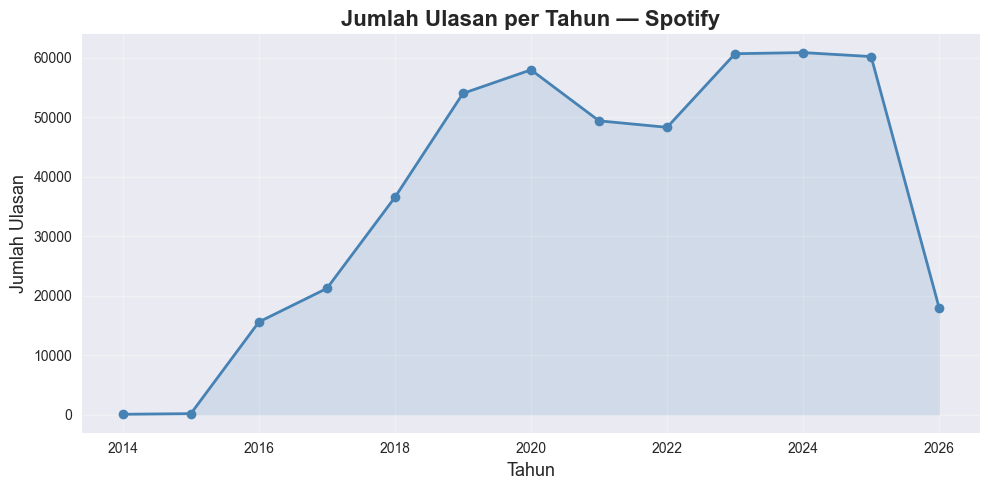

In [36]:
df_yearly = df_spotify.groupby(df_spotify['at'].dt.year).size()

plt.figure(figsize=(10, 5))
plt.plot(df_yearly.index, df_yearly.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(df_yearly.index, df_yearly.values, alpha=0.15, color='steelblue')

plt.title('Jumlah Ulasan per Tahun — Spotify', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=13)
plt.ylabel('Jumlah Ulasan', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Tren Rata-rata Skor Tahunan

Evaluasi fluktuasi tingkat kepuasan pengguna dilakukan dengan menghitung rata-rata skor ulasan per tahun untuk mengamati apakah kualitas pengalaman pengguna cenderung meningkat, stabil, atau menurun secara kronologis.

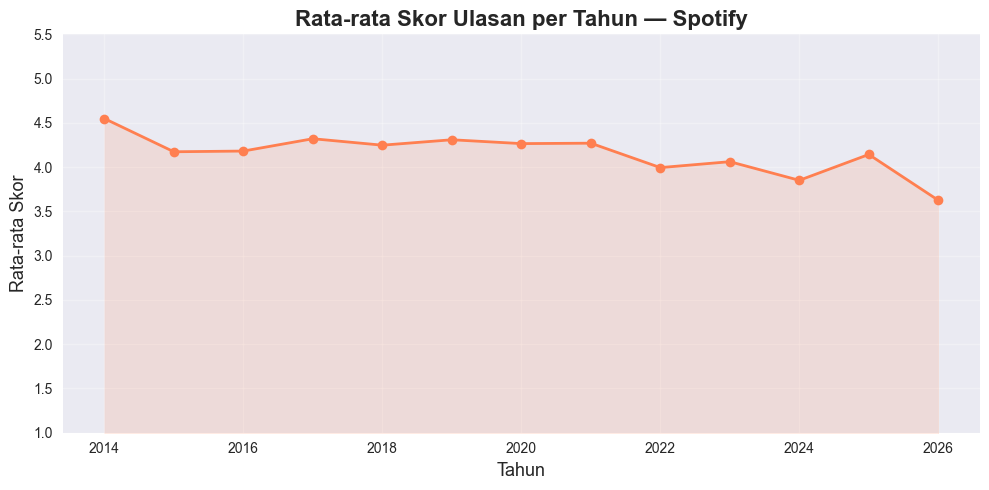

In [37]:
df_yearly_score = df_spotify.groupby(df_spotify['at'].dt.year)['score'].mean()

plt.figure(figsize=(10, 5))
plt.plot(df_yearly_score.index, df_yearly_score.values, marker='o', linewidth=2, color='coral')
plt.fill_between(df_yearly_score.index, df_yearly_score.values, alpha=0.15, color='coral')

plt.title('Rata-rata Skor Ulasan per Tahun — Spotify', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=13)
plt.ylabel('Rata-rata Skor', fontsize=13)
plt.ylim(1, 5.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##Distribusi Panjang Ulasan

Sebaran jumlah karakter pada setiap ulasan dianalisis melalui histogram untuk memahami kecenderungan pengguna dalam menyampaikan umpan balik, serta mendeteksi keberadaan pencilan (*outliers*) pada dataset.

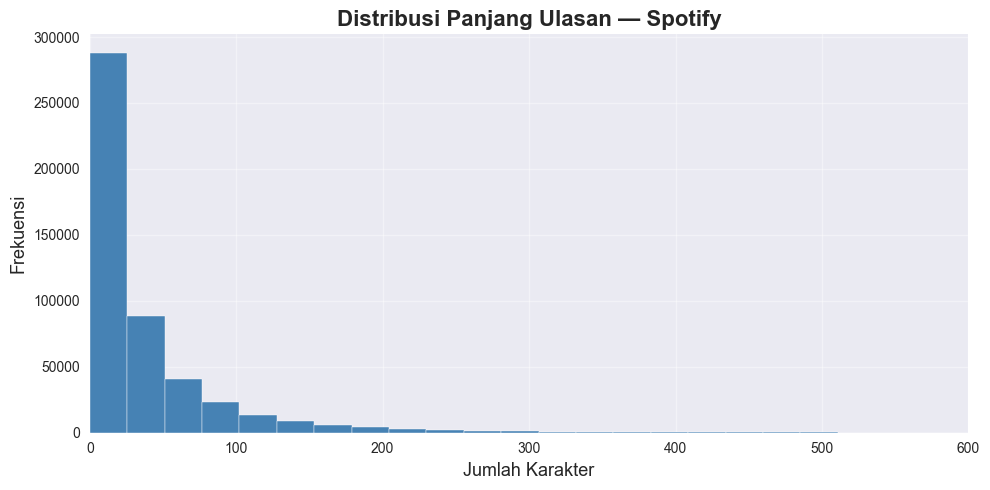

In [38]:
df_spotify['text_length'] = df_spotify['content'].fillna('').astype(str).str.len()

plt.figure(figsize=(10, 5))
plt.hist(df_spotify['text_length'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribusi Panjang Ulasan — Spotify', fontsize=16, fontweight='bold')
plt.xlabel('Jumlah Karakter', fontsize=13)
plt.ylabel('Frekuensi', fontsize=13)
plt.xlim(0, 600)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Statistik Panjang Ulasan per Skor

Hubungan antara tingkat kepuasan (skor rating) dan panjang teks ulasan ditelaah melalui perhitungan statistik deskriptif. Analisis ini memberikan gambaran mengenai pola perilaku pengguna dalam memberikan deskripsi ulasan pada setiap kategori skor.

In [39]:
df_spotify['text_length'] = df_spotify['content'].fillna('').astype(str).str.len()
df_spotify.groupby('score')['text_length'].agg(['count', 'mean', 'median', 'max'])

,count,mean,median,max
score,,,,
1,64388,69.115177,44.0,1277
2,17623,82.725529,56.0,744
3,30075,61.461513,36.0,636
4,51152,41.699425,20.0,954
5,319518,26.883284,13.0,1042


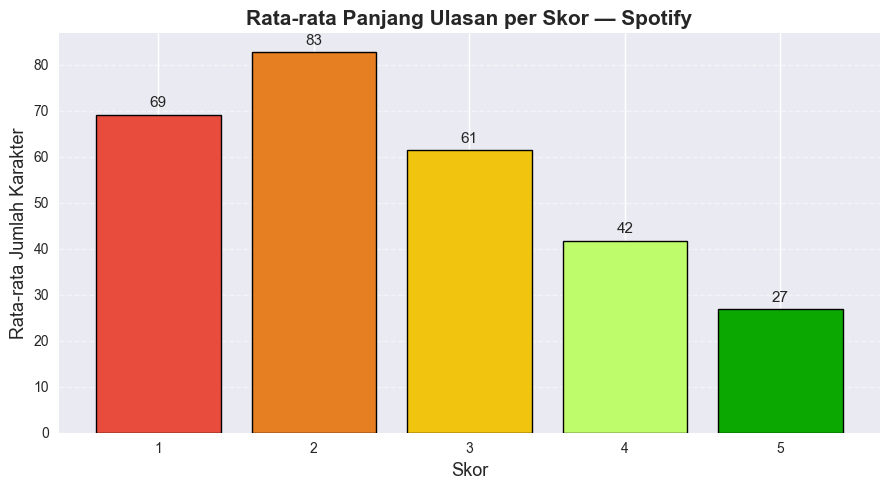

In [40]:
# Visualisasi rata-rata panjang ulasan per skor
avg_len = df_spotify.groupby('score')['text_length'].mean()

plt.figure(figsize=(9, 5))
bars = plt.bar(avg_len.index, avg_len.values,
               color=[score_colors[s] for s in avg_len.index],
               edgecolor='black', linewidth=1)

plt.title('Rata-rata Panjang Ulasan per Skor — Spotify', fontsize=15, fontweight='bold')
plt.xlabel('Skor', fontsize=13)
plt.ylabel('Rata-rata Jumlah Karakter', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.0f}", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## Analisis Frekuensi Kata

Kata kunci dominan yang paling sering muncul dalam korpus ulasan diidentifikasi menggunakan ekspresi reguler dengan filter panjang minimal tiga karakter untuk menyaring partikel kata yang tidak bermakna. Hasil 20 kata teratas divisualisasikan dalam diagram batang horizontal.

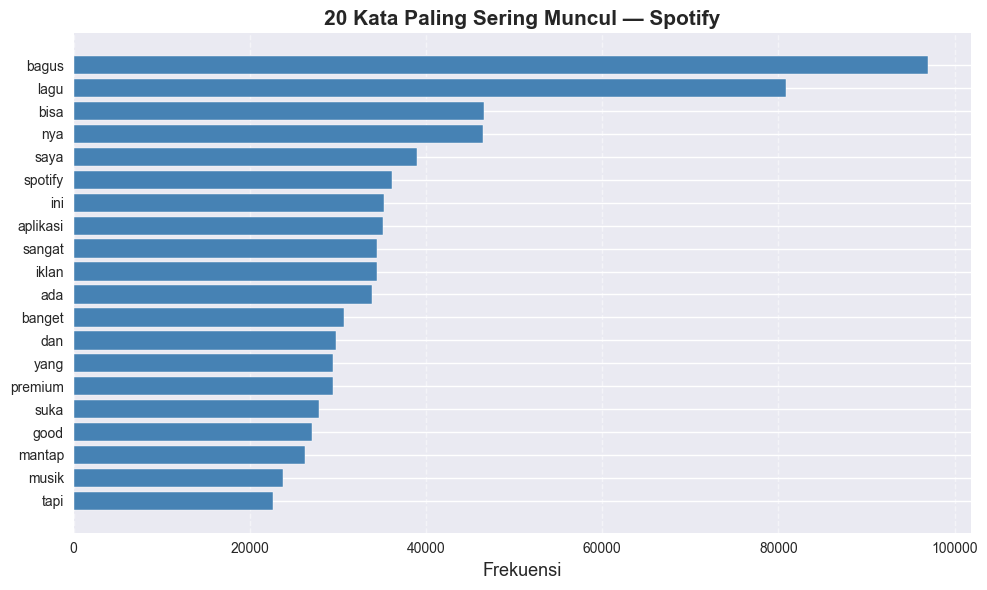

In [41]:
all_text = " ".join(df_spotify['content'].dropna()).lower()
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text)

word_counts = Counter(words).most_common(20)
labels, values = zip(*word_counts)

plt.figure(figsize=(10, 6))
plt.barh(labels, values, color='steelblue', edgecolor='white')
plt.title('20 Kata Paling Sering Muncul — Spotify', fontsize=15, fontweight='bold')
plt.xlabel('Frekuensi', fontsize=13)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Analisis Responsivitas Pengembang

Tingkat interaksi pengembang terhadap umpan balik pengguna diukur dengan mengidentifikasi keberadaan konten balasan pada atribut `replyContent`. Hasil dikategorikan dan divisualisasikan dalam diagram lingkaran untuk menunjukkan proporsi responsivitas secara keseluruhan.

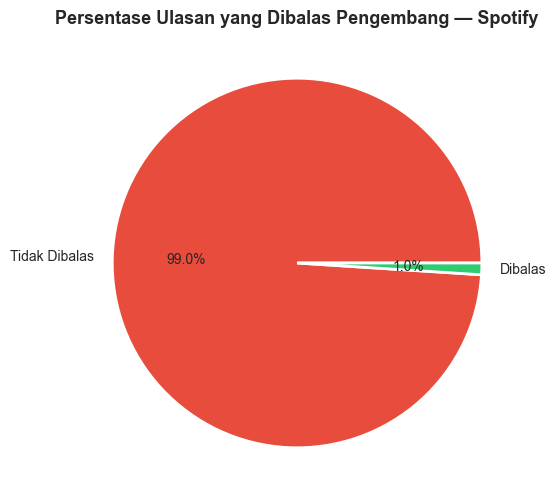

Dibalas     : 4,903 (1.0%)
Tidak dibalas: 477,853 (99.0%)


In [42]:
df_spotify['is_replied'] = df_spotify['replyContent'].notnull()
reply_counts = df_spotify['is_replied'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    reply_counts,
    labels=["Tidak Dibalas", "Dibalas"],
    autopct="%1.1f%%",
    colors=['#e74c3c', '#2ecc71'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Persentase Ulasan yang Dibalas Pengembang — Spotify', fontsize=13, fontweight='bold')
plt.show()

total = reply_counts.sum()
print(f'Dibalas     : {reply_counts[True]:,} ({reply_counts[True]/total*100:.1f}%)')
print(f'Tidak dibalas: {reply_counts[False]:,} ({reply_counts[False]/total*100:.1f}%)')

##Analisis Kecepatan Respons Pengembang

response_category
<1 hari       731
1–3 hari      117
3–7 hari        1
7–14 hari       4
14–30 hari      7
>30 hari        0
Name: count, dtype: int64


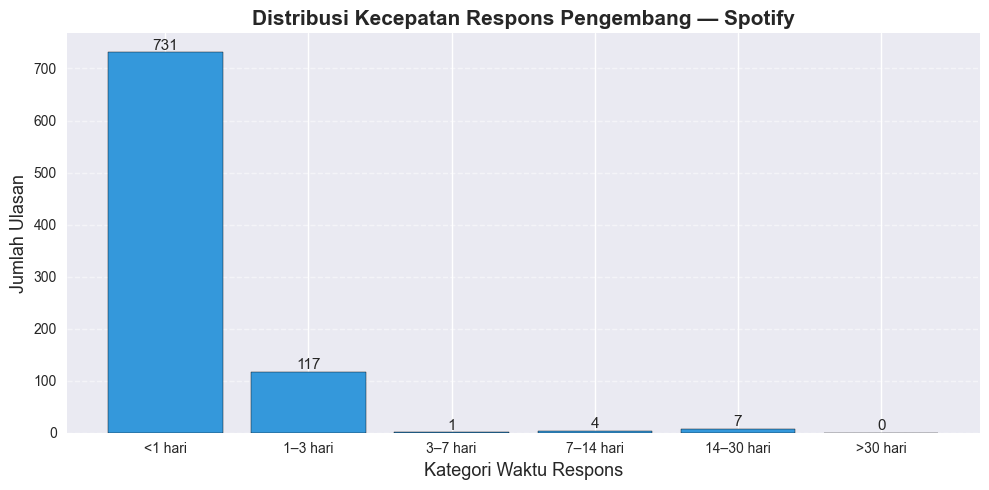

In [43]:
df_reply = df_spotify[df_spotify['replyContent'].notna()].copy()
df_reply['at'] = pd.to_datetime(df_reply['at'])
df_reply['repliedAt'] = pd.to_datetime(df_reply['repliedAt'])
df_reply['response_days'] = (df_reply['repliedAt'] - df_reply['at']).dt.days

df_reply['response_category'] = pd.cut(
    df_reply['response_days'],
    bins=[0, 1, 3, 7, 14, 30, 365],
    labels=["<1 hari", "1–3 hari", "3–7 hari", "7–14 hari", "14–30 hari", ">30 hari"]
)

resp_counts = df_reply['response_category'].value_counts().sort_index()
print(resp_counts)

# Visualisasi
plt.figure(figsize=(10, 5))
plt.bar(resp_counts.index, resp_counts.values, color='#3498db', edgecolor='black')
plt.title('Distribusi Kecepatan Respons Pengembang — Spotify', fontsize=15, fontweight='bold')
plt.xlabel('Kategori Waktu Respons', fontsize=13)
plt.ylabel('Jumlah Ulasan', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(resp_counts.values):
    plt.text(i, v + 5, f"{v:,}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Distribusi Ulasan per Bulan

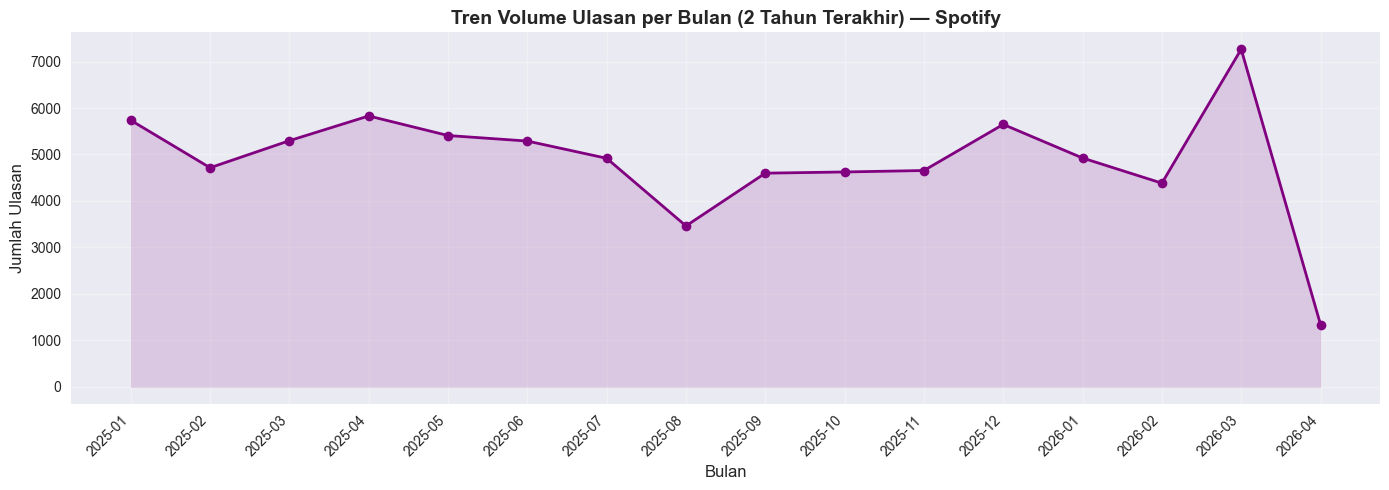

In [44]:
# Ambil data 2 tahun terakhir agar visualisasi lebih fokus
df_recent = df_spotify[df_spotify['at'].dt.year >= df_spotify['at'].dt.year.max() - 1]
df_monthly = df_recent.groupby(df_recent['at'].dt.to_period('M')).size()

plt.figure(figsize=(14, 5))
plt.plot(df_monthly.index.astype(str), df_monthly.values,
         marker='o', linewidth=2, color='purple')
plt.fill_between(df_monthly.index.astype(str), df_monthly.values, alpha=0.15, color='purple')

plt.title('Tren Volume Ulasan per Bulan (2 Tahun Terakhir) — Spotify',
          fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analisis Versi Aplikasi

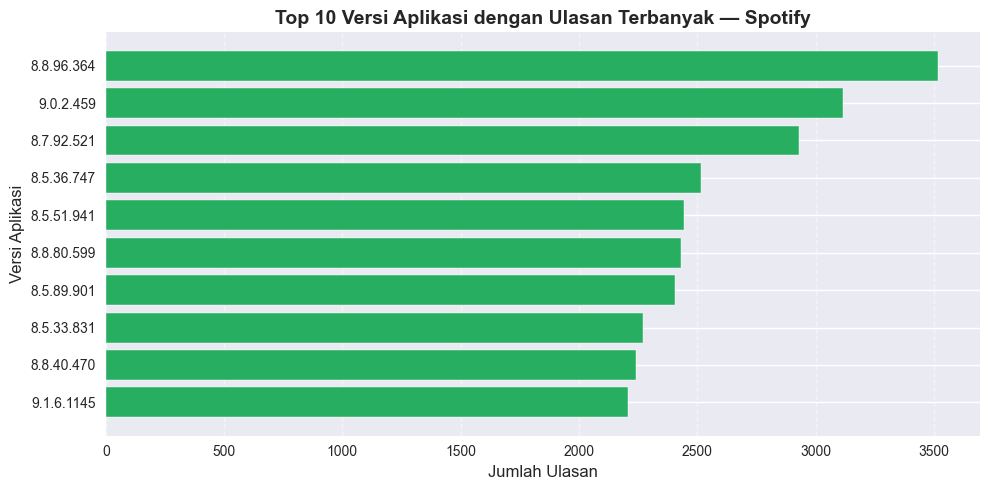

In [45]:
# Top 10 versi dengan ulasan terbanyak
top_versions = df_spotify['reviewCreatedVersion'].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_versions.index.astype(str), top_versions.values,
         color='#27ae60', edgecolor='white')
plt.title('Top 10 Versi Aplikasi dengan Ulasan Terbanyak — Spotify',
          fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Ulasan', fontsize=12)
plt.ylabel('Versi Aplikasi', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

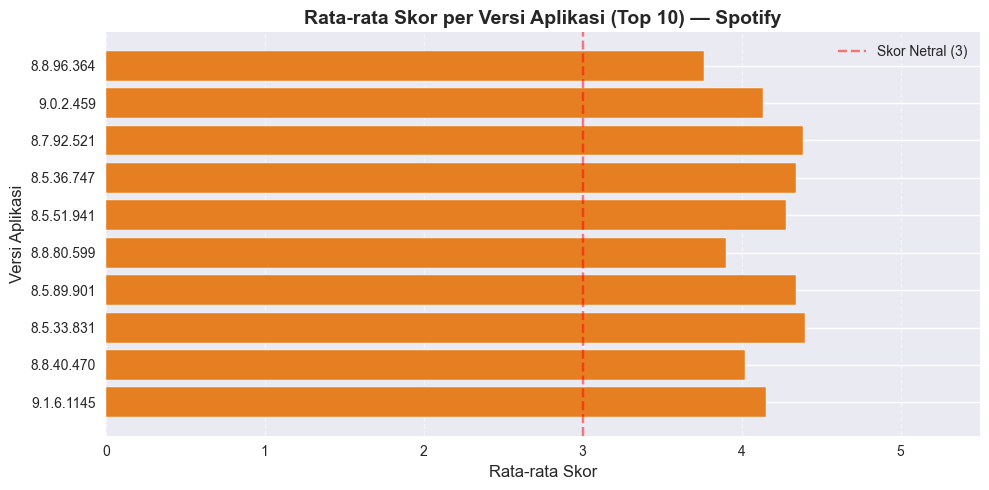

In [46]:
# Rata-rata skor per versi (top 10 versi terbanyak)
top_ver_list = top_versions.index.tolist()
avg_score_ver = (
    df_spotify[df_spotify['reviewCreatedVersion'].isin(top_ver_list)]
    .groupby('reviewCreatedVersion')['score']
    .mean()
    .reindex(top_ver_list)
)

plt.figure(figsize=(10, 5))
bars = plt.barh(avg_score_ver.index.astype(str), avg_score_ver.values,
                color='#e67e22', edgecolor='white')
plt.title('Rata-rata Skor per Versi Aplikasi (Top 10) — Spotify',
          fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Skor', fontsize=12)
plt.ylabel('Versi Aplikasi', fontsize=12)
plt.xlim(0, 5.5)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Skor Netral (3)')
plt.legend()
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()